PAREENITA A.SHIRSATH B.E.A.I.&.D.S. 49

AAI EXPERIMENT NO :  07

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 195ms/step - kl_loss: 3.4725 - loss: 277.8443 - reconstruction_loss: 274.3718 - val_kl_loss: 3.7365 - val_loss: 277.2245 - val_reconstruction_loss: 273.4880
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 191ms/step - kl_loss: 3.4816 - loss: 262.1476 - reconstruction_loss: 258.6660 - val_kl_loss: 3.7142 - val_loss: 253.8874 - val_reconstruction_loss: 250.1733
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 179ms/step - kl_loss: 3.4692 - loss: 258.8222 - reconstruction_loss: 255.3530 - val_kl_loss: 3.6170 - val_loss: 252.7298 - val_reconstruction_loss: 249.1129
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 179ms/step - kl_loss: 3.6485 - loss: 260.5005 - reconstruction_loss: 256.8520 - val_kl_loss: 3.7691 - val_loss: 250.9579 - val_reconstruction_loss: 247.1887
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 180ms/step - kl_loss: 3.4631 - loss: 265.7708 - reconstruction_loss: 262.3077 - val_kl_loss: 3.5920 - val_loss: 249.1400 - val_reconstruction_loss: 245

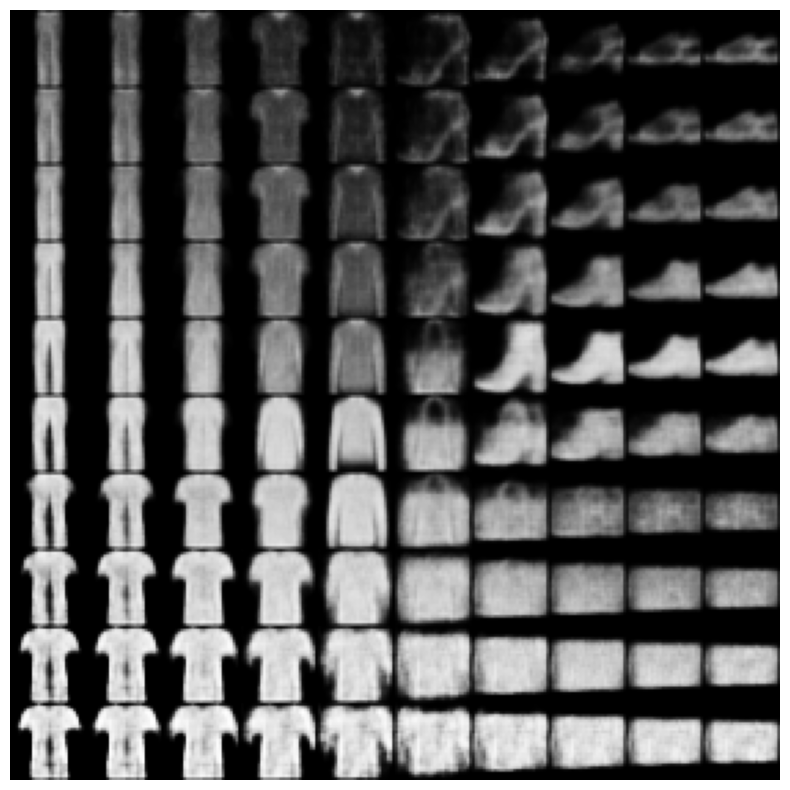

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load and Preprocess Dataset
# -------------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize and reshape
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

# -------------------------------
# 2. Define Latent Space
# -------------------------------
latent_dim = 2

# -------------------------------
# 3. Encoder
# -------------------------------
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Sampling function
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# -------------------------------
# 4. Decoder
# -------------------------------
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)

x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)

decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# -------------------------------
# 5. VAE Model
# -------------------------------
class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def compile(self, optimizer):
        super(VAE, self).compile()
        self.optimizer = optimizer

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(data, reconstruction)
            ) * 28 * 28

            # KL Divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        # Reconstruction loss
        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(data, reconstruction)
        ) * 28 * 28

        # KL Divergence loss
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        total_loss = reconstruction_loss + kl_loss

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

# -------------------------------
# 6. Train Model
# -------------------------------
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

vae.fit(x_train, epochs=10, batch_size=128, validation_data=(x_test, None))

# -------------------------------
# 7. Generate Images
# -------------------------------
def plot_generated_images():
    n = 10
    grid_x = np.linspace(-2, 2, n)
    grid_y = np.linspace(-2, 2, n)

    figure = np.zeros((28 * n, 28 * n))

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample)
            digit = x_decoded[0].reshape(28, 28)
            figure[i * 28:(i + 1) * 28,
                   j * 28:(j + 1) * 28] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap="gray")
    plt.axis("off")
    plt.show()

plot_generated_images()